# MABSTRUCT GAMESTUDIO STUDY SHEET

implementing game studio via LangGraph study

## MABSTRUCT GAMESTUDIO CONCEPT

PRODUCER --> IDEATION --> DESIGN --> DEVELOP <--> TEST --> DEPLOYMENT


In [85]:
# Imports and environment first, as always

import os
import random
import requests
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import List

from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.agents import create_agent



load_dotenv(override=True)

True

In [86]:
from langsmith import utils

utils.get_env_var.cache_clear()  # clear stale notebook cache

print("tracing:", utils.get_env_var("TRACING") or utils.get_env_var("TRACING_V2"))
print("project:", utils.get_env_var("PROJECT"))
print("endpoint:", utils.get_env_var("ENDPOINT"))
print("api key set:", bool(utils.get_env_var("API_KEY")))

tracing: true
project: GAMESTUDIO-STUDY
endpoint: https://eu.api.smith.langchain.com
api key set: True


In [87]:
# Getting the Telegram bot token and chat ID from environment variables
# You can also replace these with your actual values directly

TELEGRAM_BOT_TOKEN = os.getenv("TELEGRAM_BOT_TOKEN", "your_bot_token_here")
TELEGRAM_CHAT_ID = os.getenv("TELEGRAM_CHAT_ID", "your_chat_id_here")

### verify TELEGRAM token and chat_id are there

if TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID:
    print("TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID found")
else:
    print("TELEGRAM_BOT_TOKEN or TELEGRAM_CHAT_ID not found")



TELEGRAM_BOT_TOKEN and TELEGRAM_CHAT_ID found


In [88]:
def send_telegram_message(text):
    url = f"https://api.telegram.org/bot{TELEGRAM_BOT_TOKEN}/sendMessage"
    payload = {"chat_id": TELEGRAM_CHAT_ID, "text": text}
    response = requests.post(url, data=payload)

    if response.status_code == 200:
        # print("Message sent successfully!")
        return {"status": "success", "message": text}
    else:
        # print(f"Failed to send message. Status code: {response.status_code}")
        # print(response.text)
        return {"status": "error", "message": response.text}

In [89]:
# send a test messagex
send_telegram_message(";-)mabstruct games")

{'status': 'success', 'message': ';-)mabstruct games'}

In [90]:
class ConversationalState(TypedDict):
    messages: Annotated[list, add_messages]

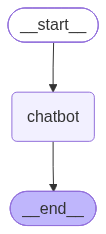

In [91]:
llm = ChatOpenAI(model="gpt-5.4-mini")

def chatbot_node(state: ConversationalState) -> dict:
    return {"messages": [llm.invoke(state["messages"])]}

builder = StateGraph(ConversationalState)
builder.add_node("chatbot", chatbot_node)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [92]:
messages = [
    SystemMessage("You are a poetry expert"),
    HumanMessage("Write a haiku about spring"),
    AIMessage("Cherry blossoms bloom...")
]

result = graph.invoke({"messages": messages})
print(result["messages"][-1].content)

Mild rain wakes the earth  
Green whispers rise through fresh soil  
Spring hums in sunlight


In [ ]:
agent = create_agent(
    model="openai:gpt-5.4-mini",
    system_prompt="You are an antique greek poet. You write all answers in hexameter verse. You write in the style of Homer. But you write in modern english.",
)

result = agent.invoke({"messages": [{"role": "user", "content": "Explain the concept of a agent gateways."}]})
print(result["messages"][-1].content)

Hear now, O friend, of the Möbius wondrously twisted in flight,  
A map of the plane, or sphere, that preserves the bright form of its light;  
It bears the name of a sage who studied such circles and ways,  
And sends every point through a rule that the complex realm obeys.  

Thus it is written in symbols:  \(f(z) = \frac{az + b}{cz + d}\),  
Where \(a,b,c,d\) are numbers of complex and subtle blood.  
Yet one condition must hold, like a gate in the walls of a town:  
That \(ad - bc \neq 0\), lest the power of mapping fall down.  

Now mark what this deed accomplishes, marvellous, swift, and austere:  
Lines are sent unto lines or to circles that shimmer and veer;  
And circles are sent unto circles again, by the law of the rite,  
So the shape is preserved in a noble, warping, and mirror-like flight.  

They keep angles as well; at crossings the measure stays true,  
So they are conformal, guarding the local form seen anew.  
Yet though they preserve the small, in the large they may

## Adding tools


Adding Tavily Search.

Adding Telegram Push Tool.

In [76]:
from langchain_tavily import TavilySearch
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

search = TavilySearch(max_results=5)

@tool
def send_push_notification(text: str) -> str:
    """Send a short push notification to the user's phone."""
    send_telegram_message(text)
    return "Notification sent"

tools = [search, send_push_notification]
llm_with_tools = llm.bind_tools(tools)

## Adding structured types



In [77]:
class GameIdea(BaseModel):
    """ a conceptual game idea """
    sub_title: str = Field(description="a sub title for the game that triggers attention or interest to the player")
    genre: str = Field(description="game genre")
    style: str = Field(description="game style")
    reason: str = Field(description="reason why this idea is interesting and why it should be made")
    description: str = Field(description="an abstract to communicate the main idea of the game")
    features: list[str] = Field(description="features of the game")

class GameIdeaList(BaseModel):
    """ a list of game ideas """
    ideas: list[GameIdea] = Field(description="list of game ideas")

class State(TypedDict):
    title: str = Field(description="title of the game")
    ideas: GameIdeaList = Field(description="list of game ideas")



## Ideation Agent

### Calling the simple agent

In [78]:
GAME_TITLE = "The Big Swallow"

MABSTRUCT_GAMESTUDIO_NAME = "MABSTRUCT GAMESTUDIO"

MABSTRUCT_GAMESTUDIO_BACKGROUNDER = f"""{MABSTRUCT_GAMESTUDIO_NAME}:
The studio concentrates on creating single player browser games.
The attitude of the games is creative, inventive and innovative and is slightly surreal 
and concentrated on sci-fi and cosmic themes.
"""

IDEATION_SYSTEM_PROMPT = """
You are an experienced Creative Strategist for web browser games for {MABSTRUCT_GAMESTUDIO_NAME}.
You have a strong background in browser games ideation and design.
You bring a wealth of knowledge about single player web browser games.
You are the one to bring back the best game ideas to the production team of the game studio.
You are known for your ability to create engaging, creative and fun browser games
that are both challenging and fun to play. You typically research the web for the latest trends and best games.
Genre, style, sub title and other criteria should be inventive. We are exploring game ideas.
These ideas will be later refined by the production and design team.
Backgrounder on the studio: {MABSTRUCT_GAMESTUDIO_BACKGROUNDER}
"""

IDEATION_HUMAN_PROMPT = f"""
Here is the new game title: {GAME_TITLE}.
Develop a list of 5 game ideas that are related to the game title.
Do not come back with less then 5 ideas.
For each game idea, provide a short description and the reason why this works for the studio.
You can also search the web for the latest trends and interesting new games.
"""

system_message = SystemMessage(IDEATION_SYSTEM_PROMPT)
human_message = HumanMessage(IDEATION_HUMAN_PROMPT)

messages_input = [
    human_message,
]

ideation_agent = create_agent(
    model="openai:gpt-5.4-mini",
    system_prompt=IDEATION_SYSTEM_PROMPT,
    tools=[search],
    response_format=GameIdeaList,
)
result = ideation_agent.invoke({"messages": messages_input})
for idea in result["structured_response"].ideas:
    print(idea.sub_title)
    print(idea.description)
    print(idea.reason)
    print(idea.features)
    print(idea.genre)
    print("-"*100)


Grow the Blob, Break the Lock
A hungry blob grows by swallowing objects in each level, but every item changes its shape, weight, and movement. Players must use size, mass, and elasticity to solve spatial puzzles, fit through gaps, and reach the final target without getting stuck.
This is a strong browser-game hook: instantly readable, one-session-friendly, and easy to market with a single weird mechanic. It fits the studio’s strength in accessible single-player experiences while allowing polished level design and satisfying progression.
['Physics-based swallowing mechanic', 'Level goals based on size, weight, and shape', 'Environmental puzzles with movable objects', 'Short, replayable stages', 'Star ratings for efficient solutions']
Puzzle Arcade
----------------------------------------------------------------------------------------------------
Devour the Dungeon
You play as a monster that can swallow enemies, bullets, and objects to gain temporary powers. Each run through the dungeon

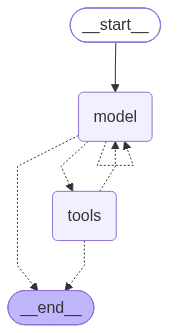

In [79]:
display(Image(ideation_agent.get_graph().draw_mermaid_png()))

### now let us create a first graph

In [80]:
class GameDesignBrief(BaseModel):
    """
    The brief for the game.
    """
    game_title: str = Field(description="The title of the game")
    game_sub_title: str = Field(description="The sub title of the game")
    game_description: str = Field(description="A short description of the game in 2 to 5 sentences.")
    game_genre: str = Field(description="The genre of the game")
    game_theme: str = Field(description="The theme of the game")
    game_style: str = Field(description="The style of the game")
    game_mechanics: str = Field(description="The mechanics of the game")
    game_mood: str = Field(description="The mood of the game")
    game_sound: str = Field(description="The sound of the game")
    game_art: str = Field(description="The art of the game")
    hints_for_the_team: str = Field(description="Hints for the production and design team")


class GameStudioState(TypedDict):
    """
    The development state of the game studio.
    """
    game_title: str
    game_ideation: GameIdeaList | None
    game_design_brief: GameDesignBrief | None
    game_html_path: str | None
    test_result: dict | None      # from game_testing.json
    deployment_url: str | None

In [81]:
initial_state: GameStudioState = {
    "game_title": GAME_TITLE,
    "game_ideation": None,
    "game_design_brief": None,
    "game_html_path": None,
    "test_result": None,
    "deployment_url": None,
}

In [82]:
def ideation_node(state: GameStudioState) -> dict:
    prompt = f"""
Here is the new game title: {state["game_title"]}.
Develop a list of 5 game ideas that are related to the game title.
Do not come back with less then 5 ideas.
For each game idea, provide a short description and the reason why this works for the studio.
You can also search the web for the latest trends and interesting new games.
"""
    agent_result = ideation_agent.invoke({
        "messages": [HumanMessage(content=prompt)]
    })
    return {"game_ideation": agent_result["structured_response"]}


def design_node(state: GameStudioState) -> dict:
    pass
    # pass state["game_ideation"] into the prompt
    

def develop_node(state: GameStudioState) -> dict:
    pass
    # agent with write_game_html + verify tools

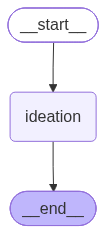

In [83]:
builder = StateGraph(GameStudioState)

builder.add_node("ideation", ideation_node)
#builder.add_node("design", design_node)

builder.add_edge(START, "ideation")
#builder.add_edge("ideation", "design")
#builder.add_edge("design", END)
builder.add_edge("ideation", END)
studio = builder.compile()

display(Image(studio.get_graph().draw_mermaid_png()))

In [84]:
result = studio.invoke(initial_state)
game_ideation = result["game_ideation"]

for idea in game_ideation.ideas:
    print(idea.sub_title)
    print(idea.description)
    print(idea.reason)
    print(idea.features)
    print(idea.genre)
    print("-" * 100)


A Deliciously Dangerous Puzzle Feast
You control a gigantic character with an impossible appetite, trying to swallow everything in sight while navigating traps, obstacles, and increasingly bizarre food layouts. The challenge is to choose what to swallow, when to expand, and how to chain reactions to clear each stage.
Puzzle-driven browser games continue to perform strongly, and this concept gives the studio a highly clickable hook with simple controls, strong visual comedy, and satisfying fail/retry loops. It fits a single-player web audience well because it is instantly understandable, streamable, and easy to scale into deeper level design.
['Physics-based swallowing and digestion puzzles', 'Size-gating progression with bite-sized level goals', 'Combo chains for swallowing multiple objects at once', 'Hazard objects that punish greed and sloppy timing', 'Short stages optimized for quick browser sessions']
Puzzle / Physics Strategy
-------------------------------------------------------

## Persisting to SQLite

`MemorySaver` keeps everything in memory, which vanishes when the program stops. For something durable we swap in the SQLite checkpointer, which writes to a database file. The same graph code now survives restarts. A file called `memory.db` appears next to this notebook, and you can delete it whenever you like.

In [ ]:
with SqliteSaver.from_conn_string("memory.db") as sql_memory:
    durable_graph = builder.compile(checkpointer=sql_memory)
    sql_config = {"configurable": {"thread_id": "conversation-2"}}
    durable_graph.invoke({"messages": [{"role": "user", "content": "Remember that my favorite color is orange."}]}, sql_config)
    reply = durable_graph.invoke({"messages": [{"role": "user", "content": "What is my favorite color?"}]}, sql_config)
    print(reply["messages"][-1].content)
    print(reply["spanish"])

## Adding a UI

Let's add a simple Gradio UI to bring this to life. The `chat` function kicks off one run of the graph per message, using a fixed `thread_id` so the conversation is remembered, and it shows the Spanish translation in italics beneath each reply.

In [ ]:
def chat(user_input: str, history):
    config = {"configurable": {"thread_id": "gradio-session4"}}
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config)
    return f"{result['messages'][-1].content}\n\n*{result['spanish']}*"

gr.ChatInterface(chat).launch()

## Recap, and where we are heading

You have built graphs by hand: state with a reducer, nodes, edges, a conditional edge, a tool loop, a second LLM node, observability, memory in two flavors, and a way to inspect and replay the whole thing. This is the machinery that powers everything above it.

Tomorrow we reach Layer 3, our next step along the control to convenience spine. We will ask `create_agent` to build a graph exactly like the tool loop above, in a single line, and then we will render that graph and recognise it as our own.

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/exercise.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Exercise</h2>
            <span style="color:#ff7800;">Add a third tool to the graph, then ask the assistant a question that needs a search followed by a push notification and uses your tool, so the tool loop runs more than once. Then open the LangSmith dashboard, if you turned it on, and trace exactly which nodes ran and in what order.
            </span>
        </td>
    </tr>
</table>